## Final cleaned dataset EDA 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
path = r"C:\Users\SVS\Desktop\ML Project\data\ml_ready\Final_dataset.csv"

final_dataset = pd.read_csv(path)

In [15]:
final_dataset.shape

(10708, 29)

In [16]:
final_dataset.head()

,id,year,state_name,state_code,district_name,district_code,crop_name,crop_code,crop_type,season,...,normal_rainfall,rainfall_deviation,agri_year,irrigation_food_category,irrigation_crop_type,irrigation_crop_name,irrigation_crop_code,irrigation_season,crop_irrigation_area,total_irrigated_area
0,385411,2019-2020,Telangana,36,Adilabad,501,Bajra,103.0,Cereals,Kharif,...,1103.8,69.931180,2019-2020,Food Crop,Cereals & Millets,Bajra,103.0,Kharif,79570.0,1048794.0
1,385812,2019-2020,Telangana,36,Kumuram Bheem Asifabad,699,Bajra,103.0,Cereals,Kharif,...,1103.8,69.931180,2019-2020,Food Crop,Cereals & Millets,Bajra,103.0,Kharif,79570.0,1048794.0
2,407355,2020-2021,Telangana,36,Kumuram Bheem Asifabad,699,Bajra,103.0,Cereals,Kharif,...,1103.6,-15.100530,2020-2021,Food Crop,Cereals & Millets,Bajra,103.0,Kharif,79635.0,1101556.0
3,450641,2022-2023,Telangana,36,Kumuram Bheem Asifabad,699,Bajra,103.0,Cereals,Kharif,...,1103.6,68.352253,2022-2023,Food Crop,Cereals & Millets,Bajra,103.0,Kharif,79128.0,1040598.0
4,284709,2014-2015,Telangana,36,Adilabad,501,Gram,201.0,Pulses,Rabi,...,1103.6,89.294537,2014-2015,Food Crop,Pulses,Gram,201.0,Rabi,2019.0,271774.0


In [17]:
final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10708 entries, 0 to 10707
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        10708 non-null  int64  
 1   year                      10708 non-null  object 
 2   state_name                10708 non-null  object 
 3   state_code                10708 non-null  int64  
 4   district_name             10708 non-null  object 
 5   district_code             10708 non-null  int64  
 6   crop_name                 10708 non-null  object 
 7   crop_code                 10708 non-null  float64
 8   crop_type                 10708 non-null  object 
 9   season                    10708 non-null  object 
 10  area                      10708 non-null  float64
 11  area_unit                 10708 non-null  object 
 12  production                10708 non-null  float64
 13  production_unit           10708 non-null  object 
 14  yield 

In [18]:
final_dataset.isnull().sum()

id                          0
year                        0
state_name                  0
state_code                  0
district_name               0
district_code               0
crop_name                   0
crop_code                   0
crop_type                   0
season                      0
area                        0
area_unit                   0
production                  0
production_unit             0
yield                       0
yield_unit                  0
old_district_name           0
actual_rainfall             0
rfs_rainfall                0
normal_rainfall             0
rainfall_deviation          0
agri_year                   0
irrigation_food_category    0
irrigation_crop_type        0
irrigation_crop_name        0
irrigation_crop_code        0
irrigation_season           0
crop_irrigation_area        0
total_irrigated_area        0
dtype: int64

In [19]:
print("Duplicate rows:", final_dataset.duplicated().sum())

Duplicate rows: 0


## Univariate Analysis 

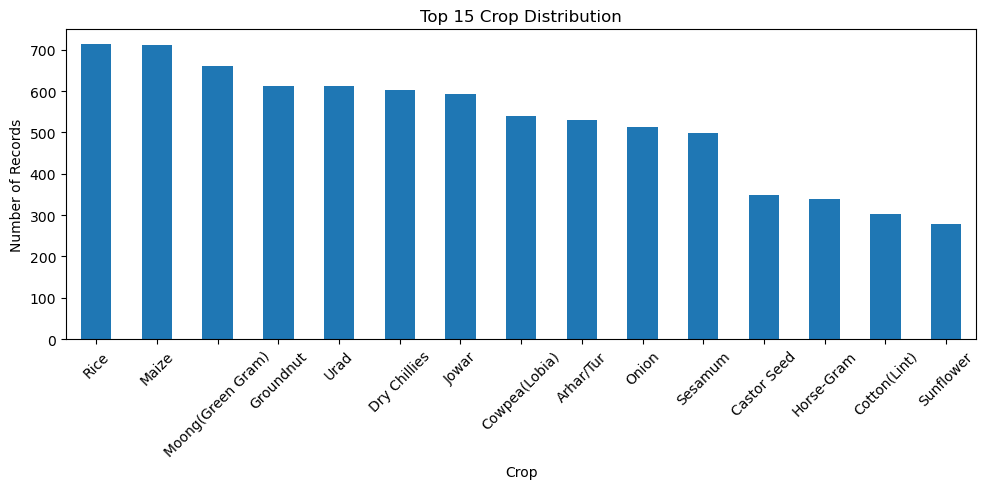

In [20]:
## Crop Distribution
plt.figure(figsize=(10, 5))

final_dataset["crop_name"].value_counts().head(15).plot(
    kind="bar"
)

plt.title("Top 15 Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

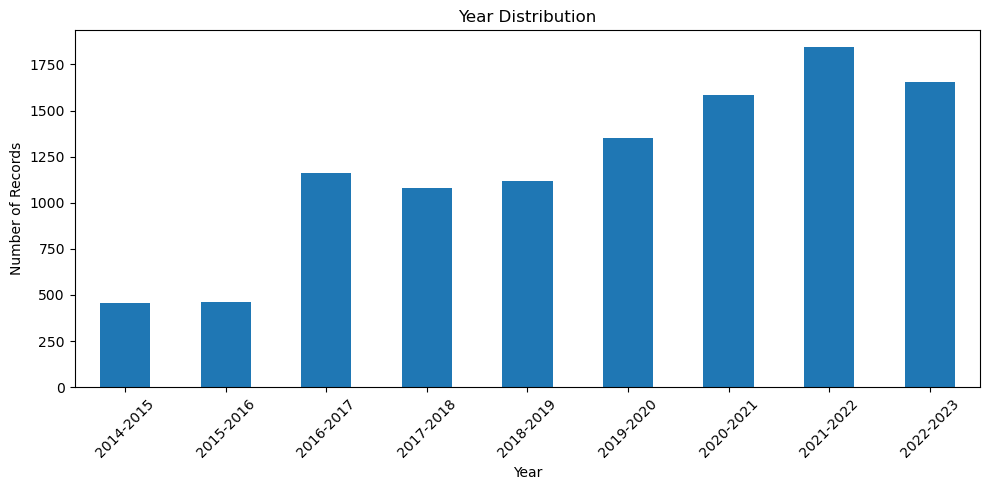

In [21]:
## Year Distribution
plt.figure(figsize=(10, 5))

final_dataset["year"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Year Distribution")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

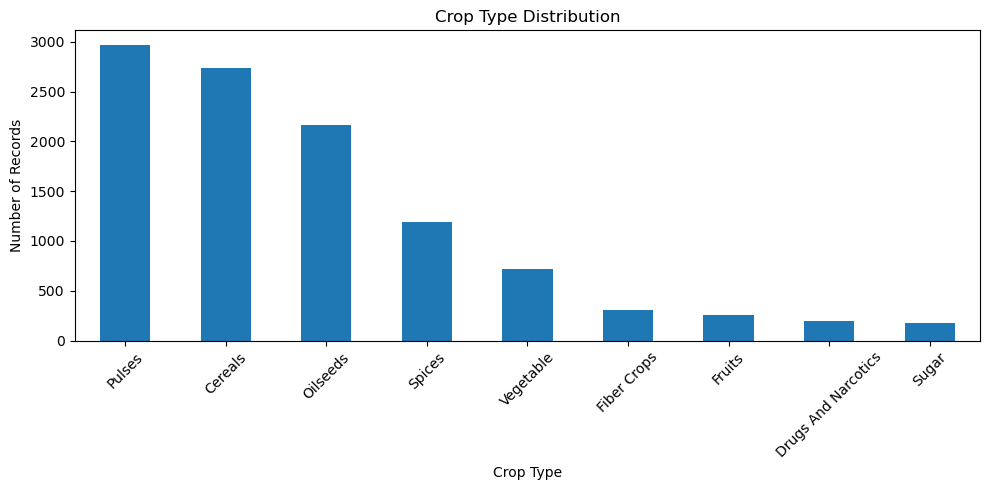

In [22]:
## Crop Type Distribution
plt.figure(figsize=(10, 5))

final_dataset["crop_type"].value_counts().plot(
    kind="bar"
)

plt.title("Crop Type Distribution")
plt.xlabel("Crop Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

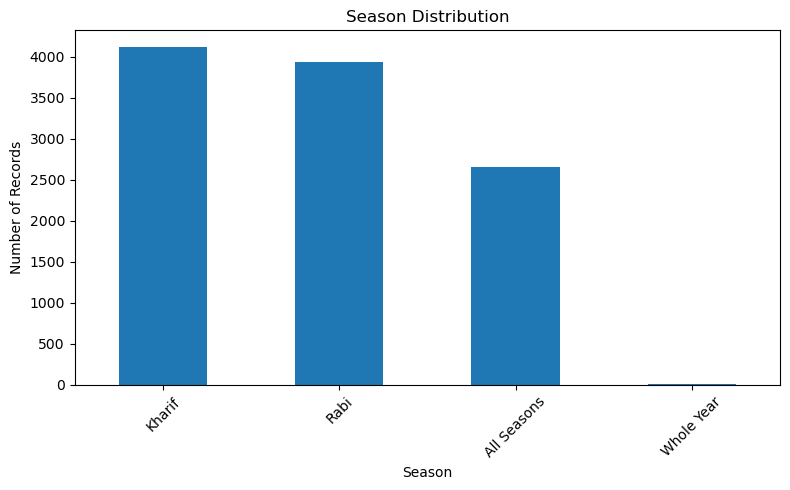

In [23]:
## Season Distribution
plt.figure(figsize=(8, 5))

final_dataset["season"].value_counts().plot(
    kind="bar"
)

plt.title("Season Distribution")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

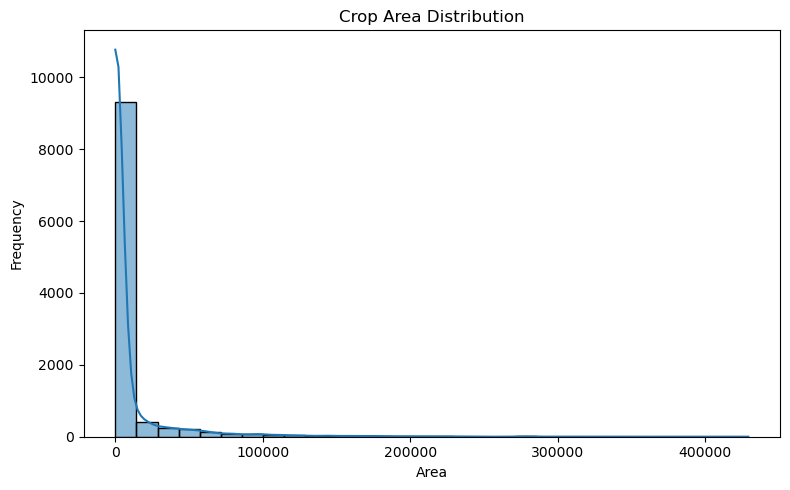

In [24]:
## Area Distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    final_dataset["area"].dropna(),
    bins=30,
    kde=True
)

plt.title("Crop Area Distribution")
plt.xlabel("Area")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

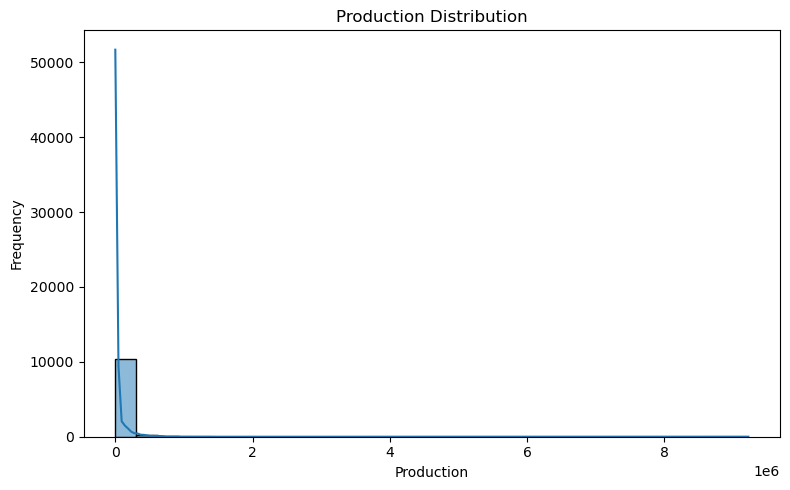

In [25]:
## Production Distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    final_dataset["production"].dropna(),
    bins=30,
    kde=True
)

plt.title("Production Distribution")
plt.xlabel("Production")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

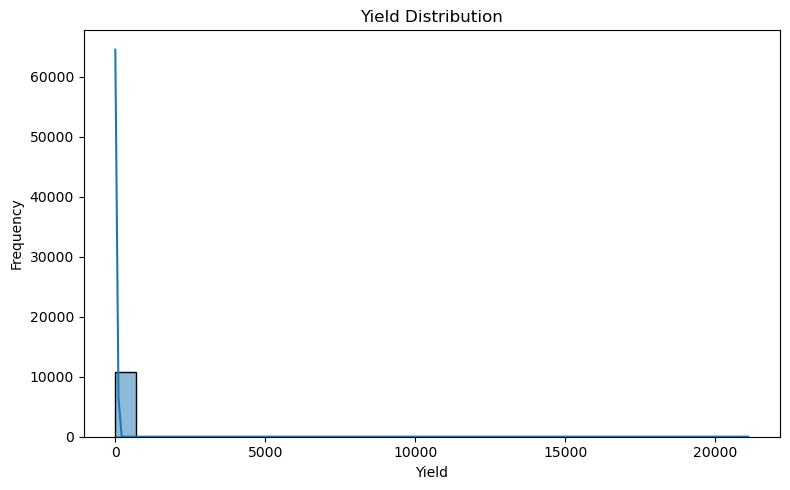

In [26]:
## Yield Distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    final_dataset["yield"].dropna(),
    bins=30,
    kde=True
)

plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

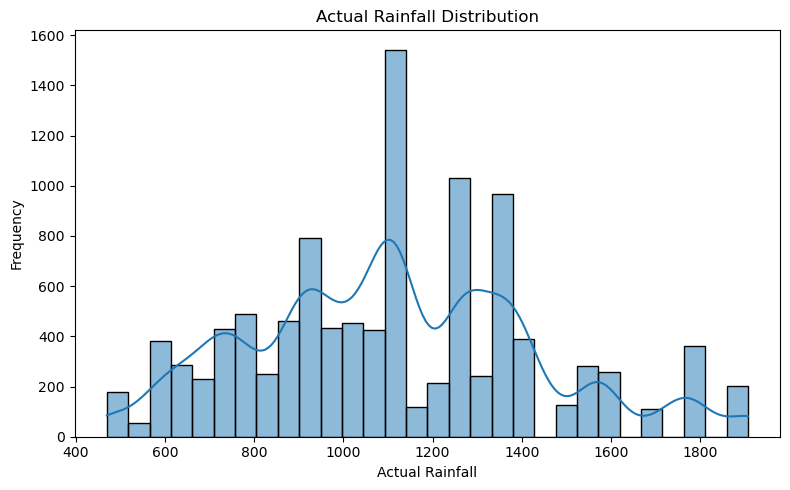

In [27]:
## Rainfall Distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    final_dataset["actual_rainfall"].dropna(),
    bins=30,
    kde=True
)

plt.title("Actual Rainfall Distribution")
plt.xlabel("Actual Rainfall")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Bivariate Analysis 

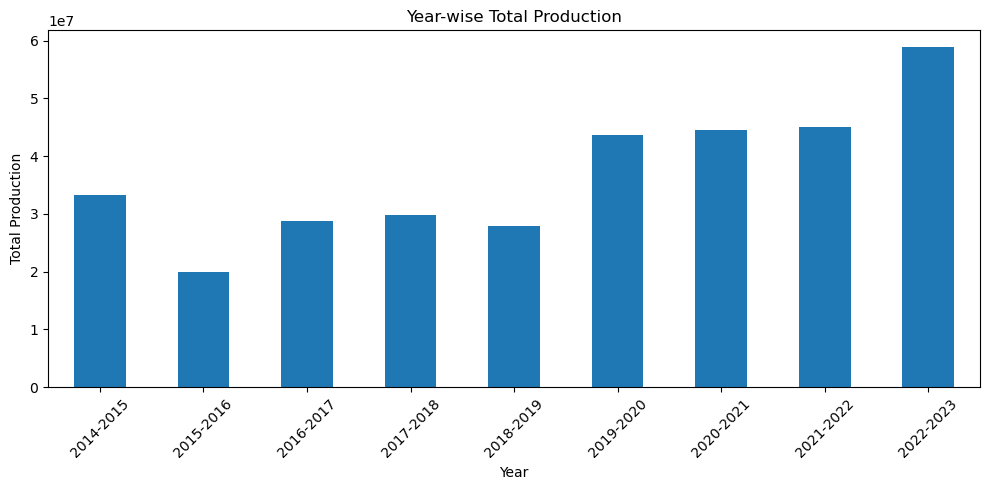

In [28]:
## Year → Production
year_production = (
    final_dataset.groupby("year")["production"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(10, 5))

year_production.plot(
    kind="bar"
)

plt.title("Year-wise Total Production")
plt.xlabel("Year")
plt.ylabel("Total Production")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

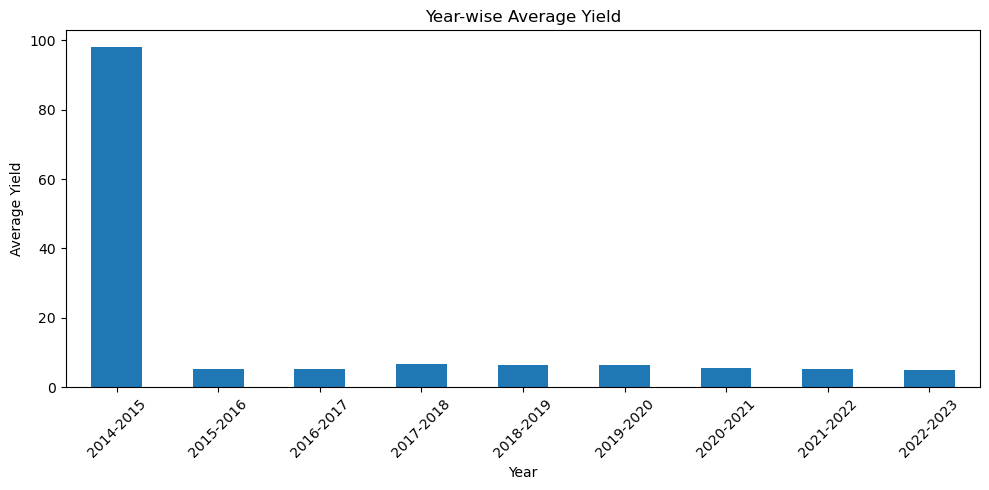

In [29]:
## Year → Yield
year_yield = (
    final_dataset.groupby("year")["yield"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(10, 5))

year_yield.plot(
    kind="bar"
)

plt.title("Year-wise Average Yield")
plt.xlabel("Year")
plt.ylabel("Average Yield")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

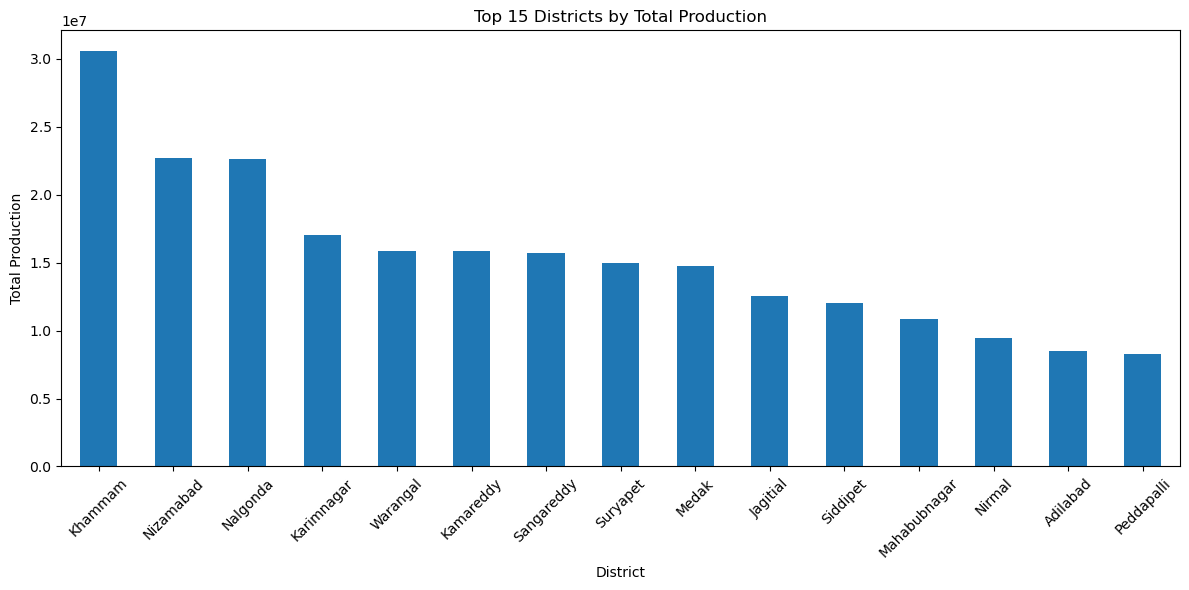

In [30]:
## District → Production
district_production = (
    final_dataset.groupby("district_name")["production"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))

district_production.plot(
    kind="bar"
)

plt.title("Top 15 Districts by Total Production")
plt.xlabel("District")
plt.ylabel("Total Production")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

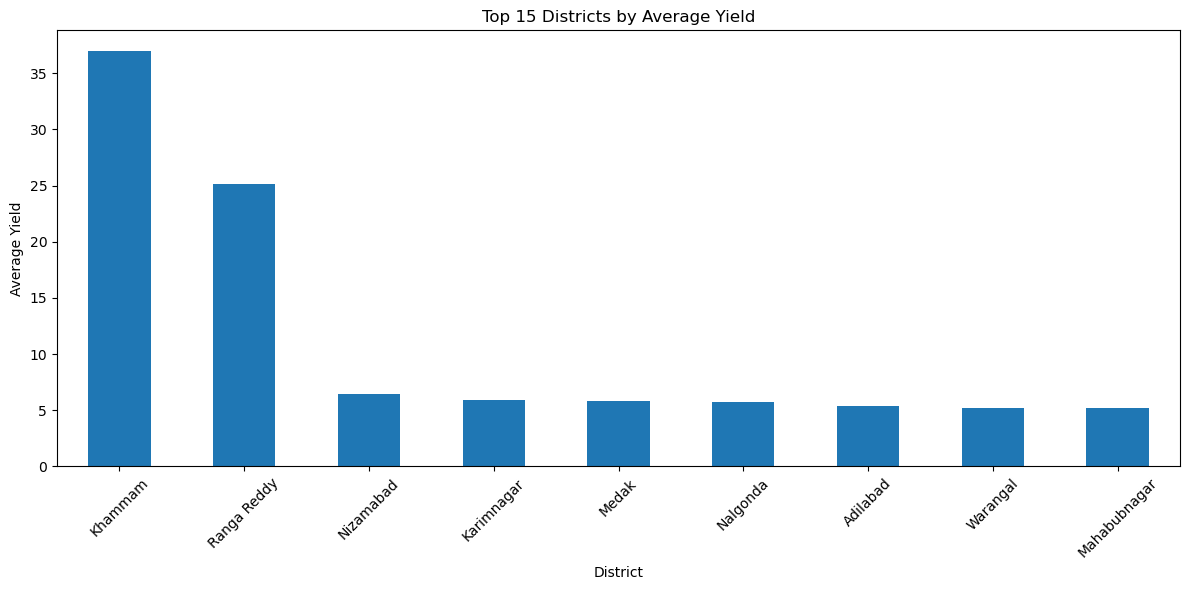

In [31]:
## District → Yield
district_yield = (
    final_dataset.groupby("old_district_name")["yield"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))

district_yield.plot(
    kind="bar"
)

plt.title("Top 15 Districts by Average Yield")
plt.xlabel("District")
plt.ylabel("Average Yield")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

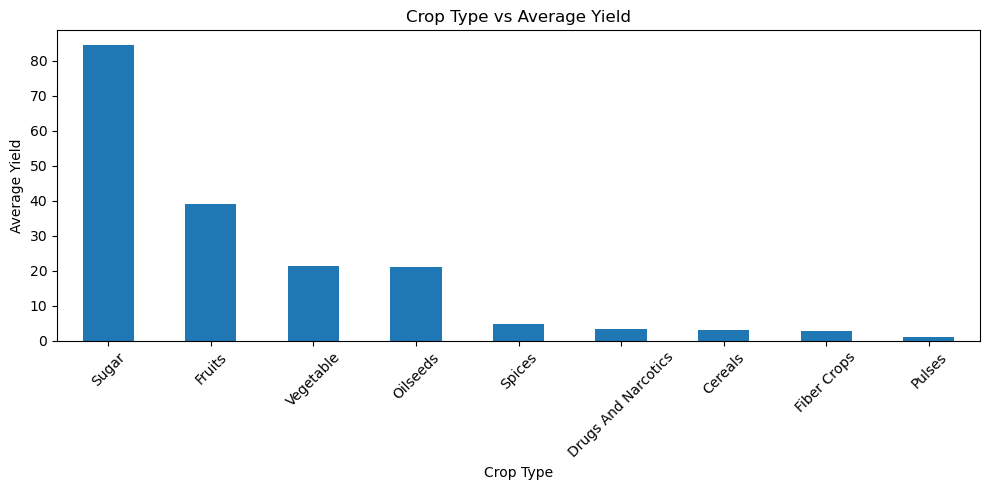

In [32]:
## Crop Type → Yield
crop_type_yield = (
    final_dataset.groupby("crop_type")["yield"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

crop_type_yield.plot(
    kind="bar"
)

plt.title("Crop Type vs Average Yield")
plt.xlabel("Crop Type")
plt.ylabel("Average Yield")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

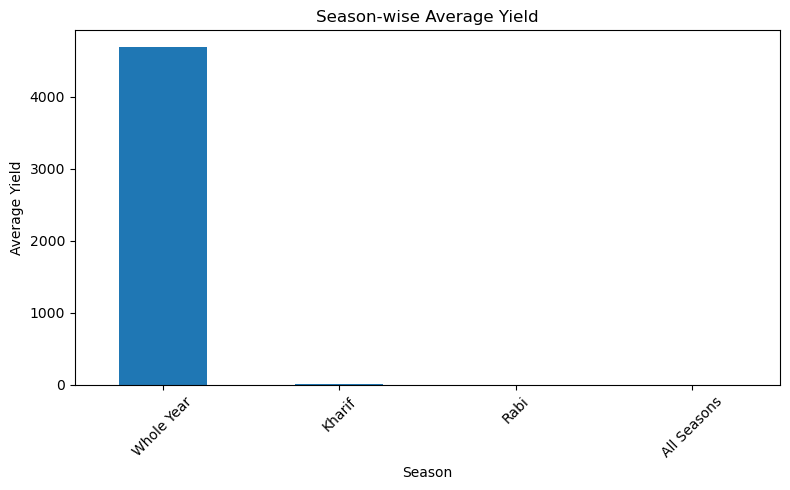

In [33]:
## Season → Yield
season_yield = (
    final_dataset.groupby("season")["yield"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

season_yield.plot(
    kind="bar"
)

plt.title("Season-wise Average Yield")
plt.xlabel("Season")
plt.ylabel("Average Yield")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

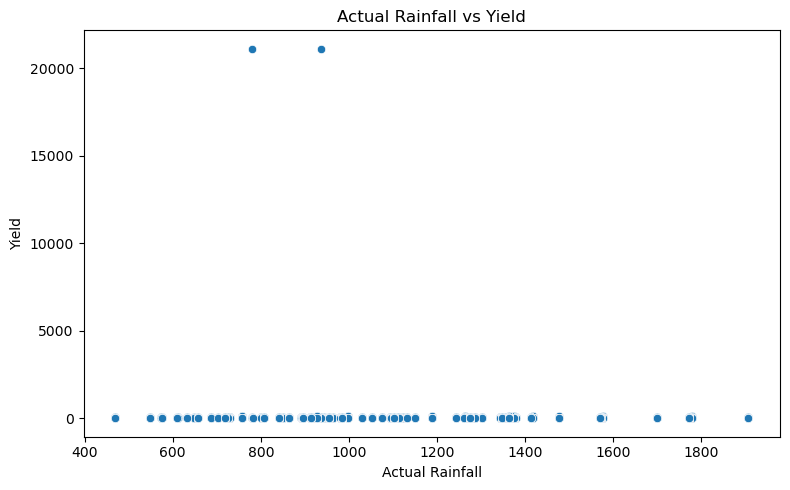

In [34]:
## Rainfall → Yield
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=final_dataset,
    x="actual_rainfall",
    y="yield"
)

plt.title("Actual Rainfall vs Yield")
plt.xlabel("Actual Rainfall")
plt.ylabel("Yield")
plt.tight_layout()
plt.show()

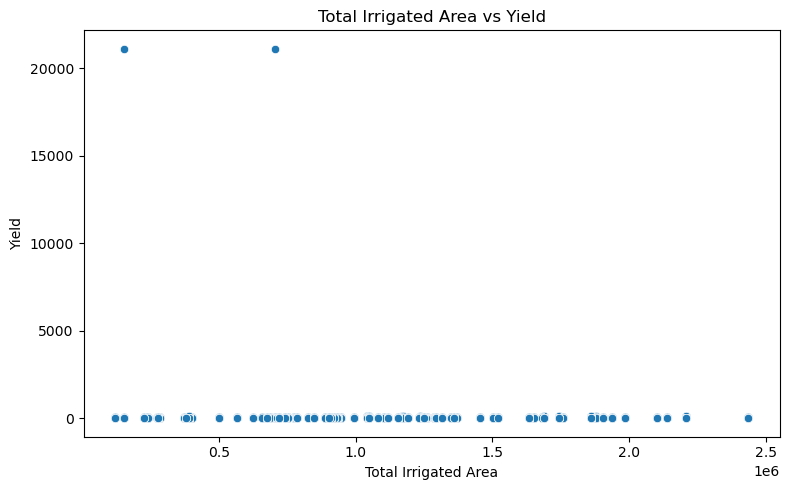

In [35]:
## Irrigation → Yield
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=final_dataset,
    x="total_irrigated_area",
    y="yield"
)

plt.title("Total Irrigated Area vs Yield")
plt.xlabel("Total Irrigated Area")
plt.ylabel("Yield")
plt.tight_layout()
plt.show()

## Multivariate Analysis

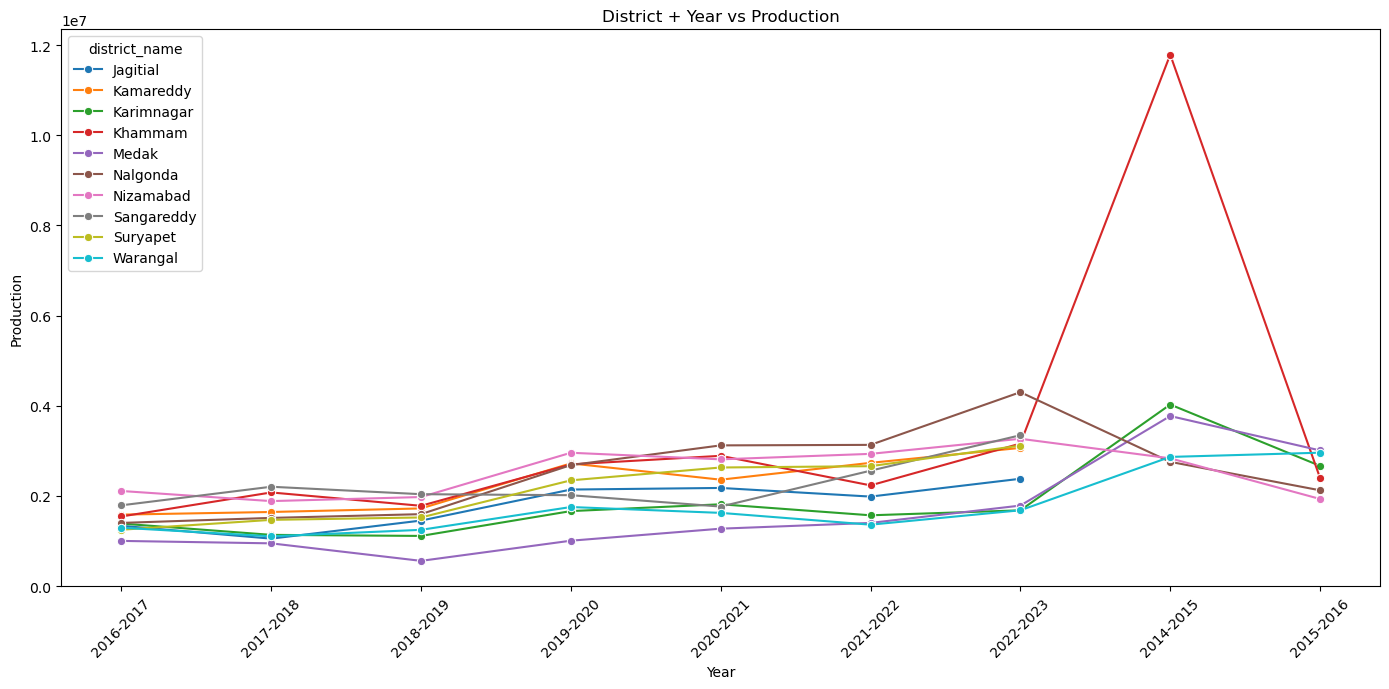

In [36]:
## District + Year → Production
district_year_production = (
    final_dataset
    .groupby(["district_name", "year"])["production"]
    .sum()
    .reset_index()
)

top_districts = (
    final_dataset.groupby("district_name")["production"]
    .sum()
    .nlargest(10)
    .index
)

plot_data = district_year_production[
    district_year_production["district_name"].isin(top_districts)
]

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=plot_data,
    x="year",
    y="production",
    hue="district_name",
    marker="o"
)

plt.title("District + Year vs Production")
plt.xlabel("Year")
plt.ylabel("Production")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

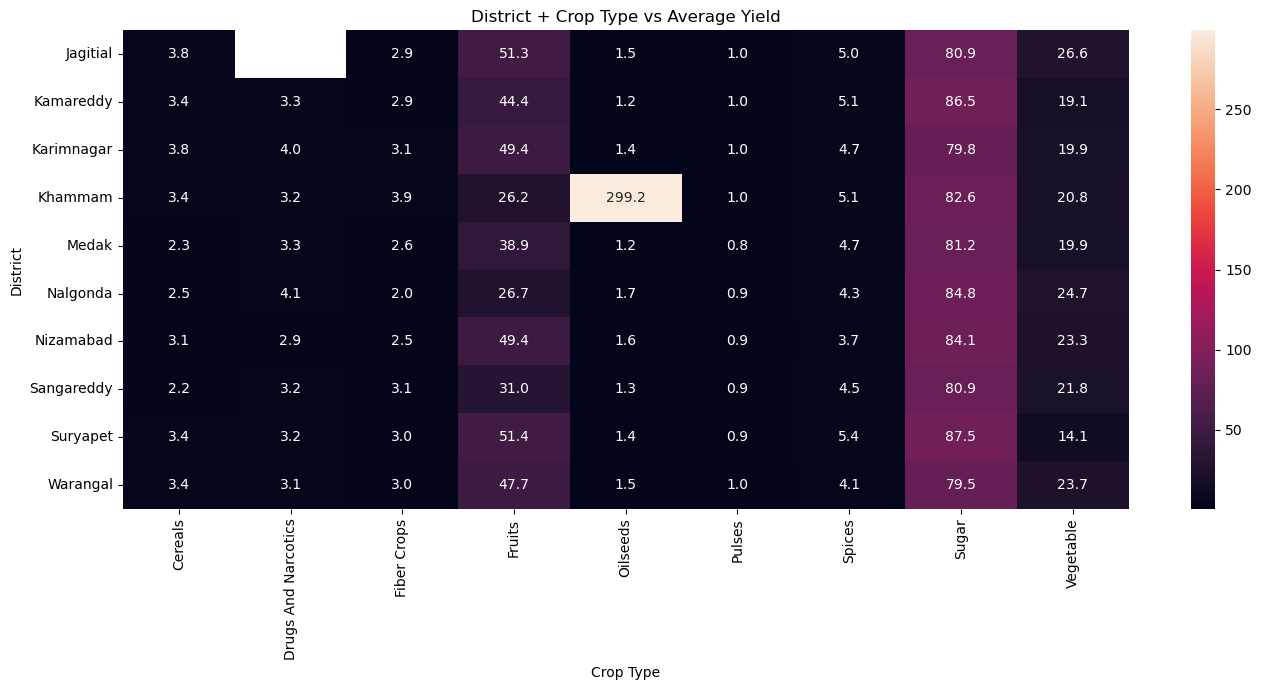

In [37]:
## District + Crop Type → Yield
data = (
    final_dataset
    .groupby(["district_name", "crop_type"])["yield"]
    .mean()
    .reset_index()
)

top_districts = (
    final_dataset.groupby("district_name")["production"]
    .sum()
    .nlargest(10)
    .index
)

data = data[
    data["district_name"].isin(top_districts)
]

pivot_data = data.pivot(
    index="district_name",
    columns="crop_type",
    values="yield"
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    pivot_data,
    annot=True,
    fmt=".1f"
)

plt.title("District + Crop Type vs Average Yield")
plt.xlabel("Crop Type")
plt.ylabel("District")
plt.tight_layout()
plt.show()

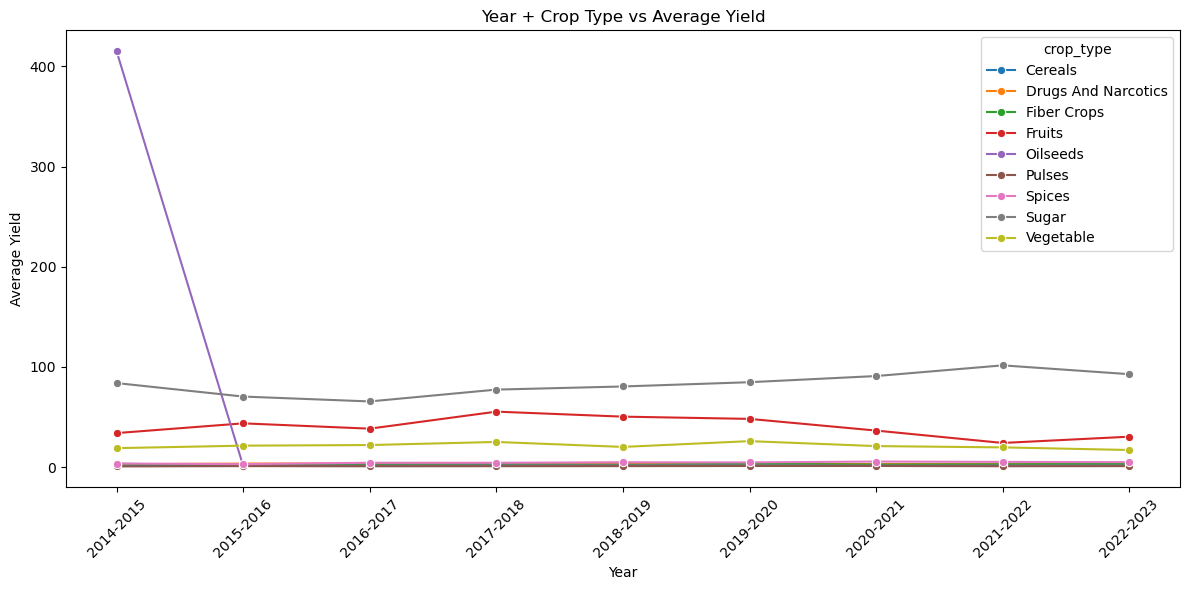

In [38]:
## Year + Crop Type → Yield
year_crop_yield = (
    final_dataset
    .groupby(["year", "crop_type"])["yield"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=year_crop_yield,
    x="year",
    y="yield",
    hue="crop_type",
    marker="o"
)

plt.title("Year + Crop Type vs Average Yield")
plt.xlabel("Year")
plt.ylabel("Average Yield")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

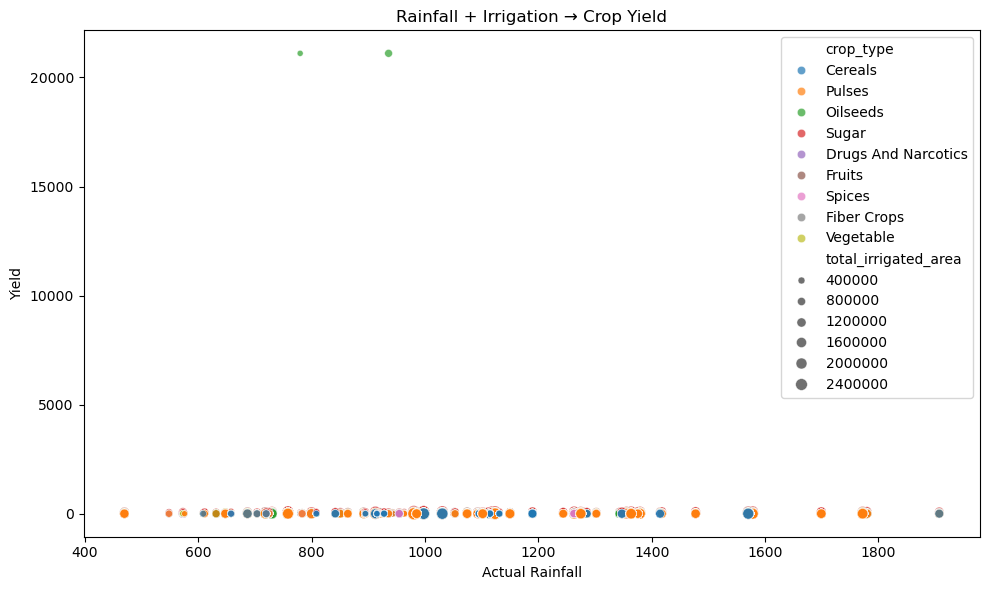

In [39]:
## Rainfall + Irrigation → Yield
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=final_dataset,
    x="actual_rainfall",
    y="yield",
    size="total_irrigated_area",
    hue="crop_type",
    alpha=0.7
)

plt.title("Rainfall + Irrigation → Crop Yield")
plt.xlabel("Actual Rainfall")
plt.ylabel("Yield")
plt.tight_layout()
plt.show()

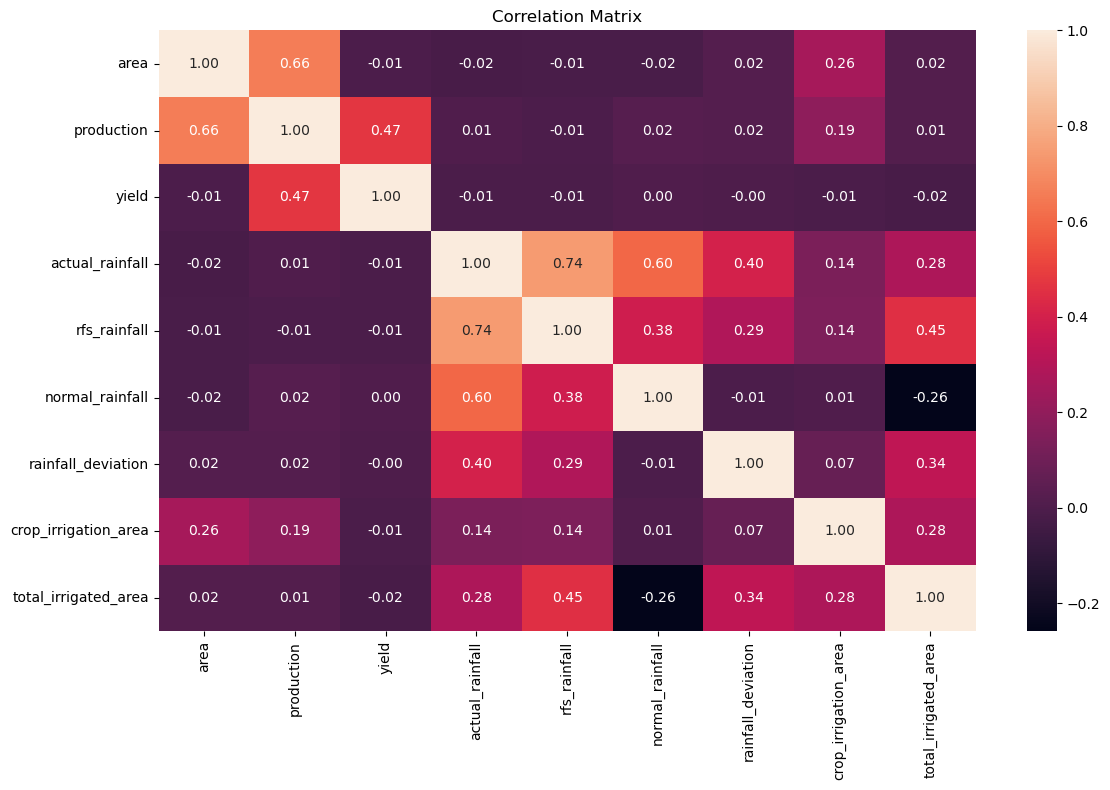

In [40]:
## Correlation Analysis
numeric_cols = [
    "area",
    "production",
    "yield",
    "actual_rainfall",
    "rfs_rainfall",
    "normal_rainfall",
    "rainfall_deviation",
    "crop_irrigation_area",
    "total_irrigated_area"
]

corr = final_dataset[numeric_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [41]:
# Save the loaded dataset
output_path = r"C:\Users\SVS\Desktop\ML Project\data\ml_ready\Final_dataset_EDA.csv"

apy.to_csv(output_path, index=False)

print("Dataset saved successfully!")
print(output_path)

Dataset saved successfully!
C:\Users\SVS\Desktop\ML Project\data\ml_ready\Final_dataset_EDA.csv



#### Insights
1. Area and Production have a positive relationship
- The correlation between Area and Production is 0.6602, which shows a moderate positive relationship.
- This means production generally increases as cultivated area increases. However, this relationship does not mean that larger land area automatically gives higher productivity.
    
2. Area has almost no direct relationship with Yield
- The correlation between Area and Yield is -0.0067, which is almost zero.
- This shows that cultivated area may influence total production, but larger land area does not necessarily result in higher yield or productivity.

3. Districts show large differences in average yield
- Khammam has an average yield of 36.96, while Ranga Reddy has 25.16; districts such as Warangal have only 5.23.
- This large variation shows that agricultural productivity differs significantly between districts, making location an important factor.

4. Agricultural production varies significantly across years
- Total production was 33.19 million in 2014–2015, decreased to 19.99 million in 2015–2016, and reached 58.82 million in 2022–2023.
- This shows that agricultural production has changed considerably across years rather than following a constant pattern.

5. Khammam has the highest total production
- Khammam recorded approximately 30.57 million total production, followed by Nizamabad with 22.70 million and Nalgonda with 22.63 million.
- This shows that agricultural production is unevenly distributed across districts, with some districts contributing substantially more.

6. Average yield differs greatly between crop types
- Sugar has an average yield of 84.48, followed by Fruits at 39.00 and Vegetables at 21.28, while Pulses have only 0.93.
- This indicates that crop productivity differs strongly by crop type, so crop category is an important factor for agricultural analysis.

7. Kharif has higher average yield than Rabi
- Kharif has an average yield of 8.55, whereas Rabi has an average yield of 4.01.
- This shows that historical crop productivity differs between seasons, suggesting that seasonal conditions should be considered during pre-cultivation planning.

8. Rainfall does not show a strong direct linear relationship with Yield
- The correlation between Actual Rainfall and Yield is approximately -0.0115, which is very close to zero.
- This suggests that rainfall alone cannot directly explain yield differences; crop type, district, irrigation, and other agricultural factors also need to be considered.

9. Total Irrigated Area has a weak direct relationship with Yield
- The correlation between Total Irrigated Area and Yield is -0.0208, which is very close to zero.
- This indicates that simply having a larger total irrigated area does not directly result in higher yield across all crops and districts.

10. Rainfall, irrigation and yield need to be analysed together
-The graph combines Actual Rainfall on the X-axis, Yield on the Y-axis, Total Irrigated Area as point size, and Crop Type as colour.
-The pattern shows that yield cannot be understood using rainfall alone, supporting the need to consider rainfall, irrigation, and crop type together.
